### [Quick Start Guide](https://ankandrew.github.io/fast-alpr/latest/quick_start/) for ALPR Package ###

**Import Statements**

Functions Imported from ocr_utils:

* crop_img_yolo

* aplr_single_image

* annotate_images_ocr

In [1]:
import os
import sys
import os
import numpy as np
from fast_alpr import ALPR
import pandas as pd
import cv2

# Get the path of the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add it to the Python search path if it isn't there already
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils.ocr_utils import alpr_single_image, do_alpr

**Define Image and Annotation paths**

In [2]:
# folder path to training data
train_img_path = r"../data/license_plate_detection/train/images"
train_anno_path = r"../data/license_plate_detection/train/labels"

**Run ALPR model on single image**

In [3]:
alpr = ALPR()

test_image= r"../data/license_plate_detection/train/images/lp_train_972.jpg"
test_cv2 = cv2.imread(test_image)

alpr_single_image(alpr, test_cv2,"lp_train_972")

INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['AzureExecutionProvider', 'CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.pipeline.license_plate:Initialized LicensePlateDetector with model C:\Users\Installer\.cache\open-image-models\yolo-v9-t-384-license-plate-end2end\yolo-v9-t-384-license-plates-end2end.onnx


[{'bbox': [181, 290, 135, 172],
  'bbox_norm': [0.3834745762711864,
   0.614406779661017,
   0.44554455445544555,
   0.5676567656765676],
  'confidence': [0.998153030872345,
   0.9999368190765381,
   0.9997872710227966,
   0.9999889135360718,
   0.9997684359550476,
   0.9999608993530273,
   0.9998819828033447,
   0.9999518394470215,
   0.9999077320098877,
   0.9999850988388062],
  'label': 'License Plate',
  'text': '51F07973',
  'region': 'Vietnam',
  'region_confidence': 1.0,
  'file_name': 'lp_train_972'}]

**Main OCR Function**

* runs set of images and annotations through OCR process
* returns dataframe with OCR predictions for each image

In [ ]:
output_df = do_alpr(train_anno_path, train_img_path)

**Save result to CSV**

In [ ]:
save_path = r"..\data\alpr_ocr_results.csv"

output_df.to_csv(save_path)

**Summary Statistics**

In [4]:
import seaborn as sns
import ast

ocr_df = pd.read_csv(r"..\data\alpr_ocr_results.csv")

def func(input_str):
    if pd.isna(input_str):
        return float('nan')
    
    inp_list = ast.literal_eval(input_str)
    fl_list = [item for item in inp_list if isinstance(item, float)]

    return sum(fl_list)/len(fl_list)

def func1(input_str):
    if pd.isna(input_str):
        return float('nan')
    
    
    inp_list = ast.literal_eval(input_str)
    if len(inp_list) == 4:

        ctr_x = (inp_list[0]+inp_list[1])/2
        ctr_y = (inp_list[2]+inp_list[3])/2

    return (ctr_x, ctr_y)

def func2(input_str):
    if pd.isna(input_str):
        return float('nan')
    
    
    inp_list = ast.literal_eval(input_str)
    if len(inp_list) == 4:

        return(inp_list[1]-inp_list[0])*(inp_list[3]-inp_list[2])

total = ocr_df.shape[0]
na_counts = ocr_df['text'].isna().sum()
na_region_counts = ocr_df['region'].isna().sum()

print(f"Regions Detected: {(1-na_region_counts/total)*100:.2f}% \n")
print(f"Licence plates with extracted text: {(1-na_counts/total)*100:.2f}% \n")

print(f"Regions detected and value counts: {ocr_df["region"].value_counts()}")

ocr_df = ocr_df.dropna(subset= ["text"])
ocr_df["avg_confidence"] = ocr_df["confidence"].apply(func)
ocr_df["center_norm"] = ocr_df["bbox_norm"].apply(func1)
ocr_df["area_norm"] = ocr_df["bbox_norm"].apply(func2)

Regions Detected: 65.01% 

Licence plates with extracted text: 64.58% 

Regions detected and value counts: region
Vietnam                   3635
United States              347
Mexico                     155
United Kingdom             112
Unknown                     54
Spain                       49
Greece                      28
Israel                      26
Norway                      26
Canada                      23
Germany                     21
Turkey                      20
Switzerland                 20
Netherlands                 19
Australia                   17
Brazil                      17
France                      17
New Zealand                 15
Sweden                      14
Romania                     13
Belarus                     11
Italy                        9
Ireland                      9
Belgium                      9
Singapore                    9
Armenia                      8
Azerbaijan                   8
Poland                       7
Georgia           

<Axes: xlabel='area_norm', ylabel='Count'>

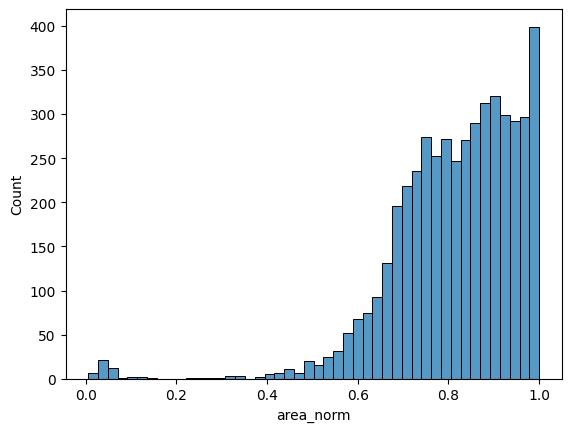

In [5]:
import seaborn as sns

sns.histplot(ocr_df, x = "area_norm")

<Axes: xlabel='x_norm', ylabel='y_norm'>

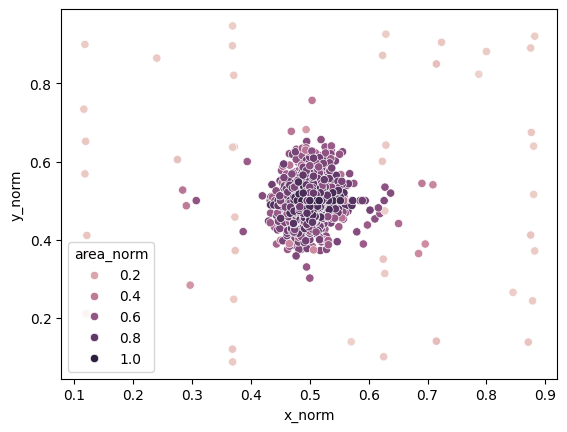

In [10]:
ocr_df[['x_norm', 'y_norm']] = pd.DataFrame(ocr_df['center_norm'].to_list(), index=ocr_df.index)
sns.scatterplot(ocr_df, x = 'x_norm', y = 'y_norm', hue = "area_norm")